# Multi-Agent Workflows + RAG - LangGraph

Today we'll be looking at an example of a Multi-Agent workflow that's powered by LangGraph, LCEL, and more!

We're going to be, more specifically, looking at a "heirarchical agent teams" from the [AutoGen: Enabling Next-Gen LLM
Applications via Multi-Agent Conversation](https://arxiv.org/pdf/2308.08155) paper.

This will be the final "graph" of our system:

![image](https://i.imgur.com/Bhc7RVE.png)

It's important to keep in mind that the actual implementation will be constructed of 3 separate graphs, the final one having 2 graphs as nodes! LangGraph is a heckuva tool!



# 🤝 BREAKOUT ROOM #1

## Dependencies

We'll start, as we normally do, by grabbing our dependencies.

We'll be using LangChain and LangGraph to power our application, so let's start by grabbing those!

In [1]:
#!pip install -qU langgraph==0.2.14 langchain==0.2.14 langchain_openai==0.1.23 langchain_core==0.2.35 langchain-community

We're going to be showing a simple RAG chain as part of our LangGraph - and so we'll need specific dependencies for that as well!

In [2]:
#!pip install -qU --disable-pip-version-check qdrant-client pymupdf tiktoken

Since we'll be relying on OpenAI's suite of models to power our agents today, we'll want to provide our OpenAI API Key.

We're also going to be using the Tavily search tool - so we'll want to provide that API key as well!

Instruction for how to obtain the Tavily API key can be found:

1. [Tavily API Key](https://app.tavily.com/sign-in)



In [3]:
import os
import getpass
from dotenv import load_dotenv

load_dotenv()

def set_api_key_if_not_present(key_name, prompt_message):
    if key_name not in os.environ or not os.environ[key_name]:
        os.environ[key_name] = getpass.getpass(prompt_message)

set_api_key_if_not_present("OPENAI_API_KEY", "OpenAI API Key:")
set_api_key_if_not_present("TAVILY_API_KEY", "TAVILY_API_KEY:")

In [4]:
from IPython.display import display, Markdown
from langchain_core.messages import AIMessage
from langchain_core.runnables import RunnableSerializable
from typing import Union, Dict, Any

def display_markdown(message : (str, AIMessage) ):
    """Display formatted Markdown text in a Jupyter notebook.
    
    Args:
        text (str): Markdown formatted text to display
    """
    if isinstance(message, AIMessage):
        display(Markdown(message.content))
    else:
        display(Markdown(message))
        
    return message

class MarkdownDisplayRunnable(RunnableSerializable):
    """A runnable that displays content as Markdown in a Jupyter notebook.
    
    Can be used in LCEL chains to display outputs.
    """
    
    def invoke(self, input: Union[str, AIMessage, Dict[str, Any]], config=None) -> Union[str, AIMessage, Dict[str, Any]]:
        """Display the input as Markdown and pass it through."""
        if isinstance(input, dict) and "output" in input:
            display_markdown(input["output"])
            return input
        else:
            display_markdown(input)
            return input    

## Task 1: Simple LCEL RAG

Now that we have our dependencies set-up - let's create a simple RAG chain that works over a single PDF.

> NOTE: While this particular example is very straight forward - you can "plug in" any complexity of chain you desire as a node in a LangGraph.

## Retrieval

The 'R' in 'RAG' - this is, at this point, fairly straightforward!

#### Data Collection and Processing

A classic first step, at this point, let's grab our desired document!

In [5]:
from langchain_community.retrievers import ArxivRetriever

arxiv_retriever = ArxivRetriever(
    load_max_docs=2,
    get_full_documents=True,
    doc_content_chars_max=None,
    load_all_available_meta=True,
)



Now we can chunk it down to size!

In [6]:
import tiktoken
from langchain.text_splitter import RecursiveCharacterTextSplitter

def tiktoken_len(text):
    tokens = tiktoken.encoding_for_model("gpt-4o-mini").encode(
        text,
    )
    return len(tokens)

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 300,
    chunk_overlap = 0,
    length_function = tiktoken_len,
)



Now we've successfully split our single PDF into...

documents!

#### Embedding Model and Vector Store

Now that we have our chunked document - lets create a vector store, which will first require us to create an embedding model to get the vector representations of our text!

We'll use OpenAI's [`text-embedding-3-small`](https://platform.openai.com/docs/guides/embeddings/embedding-models) model - as it's cheap, and performant.

In [7]:
from langchain_openai.embeddings import OpenAIEmbeddings

embedding_model = OpenAIEmbeddings(model="text-embedding-3-small")

Now we can create our QDrant backed vector store!

In [8]:
from langchain_qdrant import QdrantVectorStore
from qdrant_client import QdrantClient
from qdrant_client.http.models import Distance, VectorParams


# Create an in-memory client
client = QdrantClient(":memory:")

# Create a collection
client.create_collection(
    collection_name="extending_context_window_llama_3",
    vectors_config=VectorParams(size=1536,distance=Distance.COSINE),
)

qdrant_vectorstore = QdrantVectorStore(
    client=client,
    embedding=embedding_model,
    collection_name="extending_context_window_llama_3",
)

Let's make sure we can access it as a retriever.

In [9]:
qdrant_retriever = qdrant_vectorstore.as_retriever()

In [10]:
import functools
from operator import itemgetter
from langchain_core.retrievers import BaseRetriever
from langchain.text_splitter import TextSplitter
from langchain_core.vectorstores import VectorStore
from langchain_core.runnables import RunnableLambda
from langchain_core.output_parsers import StrOutputParser
from typing import List
def pull_from_retriever_to_vectorstore(query: str, retriever:BaseRetriever, chunker:TextSplitter, vectorStore:VectorStore) -> str:
    """Embed document into the vector store. Returns lists of URLs for the papers."""
    docs = retriever.invoke(query)
    split_chunks = chunker.split_documents(docs)
    vectorStore.add_documents(split_chunks)
    
    return {"context":"The following papers were added to the RAG vector store:\n\n" + "\n\n".join([d.metadata["Title"] for d in docs])}

pull_from_arxiv_to_qdrant = functools.partial(
    pull_from_retriever_to_vectorstore, 
    retriever=arxiv_retriever, 
    chunker=text_splitter, 
    vectorStore=qdrant_vectorstore)

arxiv_chain = itemgetter("question") | RunnableLambda(pull_from_arxiv_to_qdrant) 

### Augmented

Now that we have our retrieval process set-up, we need to set up our "augmentation" process - AKA a prompt template.

In [11]:
from langchain_core.prompts import ChatPromptTemplate

RAG_PROMPT = """
CONTEXT:
{context}

QUERY:
{question}

You are a helpful assistant. Use the available context to answer the question. If you can't answer the question, say you don't know.
"""

rag_prompt = ChatPromptTemplate.from_template(RAG_PROMPT)

### Generation

Last, but certainly not least, let's put the 'G' in 'RAG' by adding our generator - in this case, we can rely on OpenAI's [`gpt-4o-mini`](https://platform.openai.com/docs/models/gpt-4o-mini) model!

In [12]:
from langchain_openai import ChatOpenAI

openai_chat_model = ChatOpenAI(model="gpt-4o-mini")

### RAG - Retrieval Augmented Generation

All that's left to do is combine our R, A, and G into a single chain - and we're off!

In [13]:
from operator import itemgetter
from langchain.schema.output_parser import StrOutputParser

rag_chain = (
    {
        "context": itemgetter("question") | qdrant_retriever, 
        "question": itemgetter("question")
        } | 
    rag_prompt | 
    openai_chat_model | 
    StrOutputParser()
)

Let's test this out and make sure it works.

In [14]:
rag_chain.invoke({"question" : "What does the 'context' in 'long context' refer to?"})

"I don't know."

### RAG Limitation

Notice how we're hard-coding our data, while this is simply meant to be an illustrative example - you could easily extend this to work with any provied paper or document in order to have a more dynamic system.

For now, we'll stick with this single hard-coded example in order to keep complexity down in an already very long notebook!

##### 🏗️ Activity #1 (Bonus Marks)

Allow the system to dynamically fetch Arxiv papers instead of hard coding them.

> HINT: Tuesday's assignment will be very useful here.

## Task 2: Helper Functions for Agent Graphs

We'll be using a number of agents, nodes, and supervisors in the rest of the notebook - and so it will help to have a collection of useful helper functions that we can leverage to make our lives easier going forward.

Let's start with the most simple one!

#### Import Wall

Here's a wall of imports we'll be needing going forward!

In [15]:
from typing import Any, Callable, List, Optional, TypedDict, Union

from langchain.agents import AgentExecutor, create_openai_functions_agent
from langchain.output_parsers.openai_functions import JsonOutputFunctionsParser
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.messages import AIMessage, BaseMessage, HumanMessage
from langchain_core.runnables import Runnable
from langchain_core.tools import BaseTool
from langchain_openai import ChatOpenAI

from langgraph.graph import END, StateGraph

### Agent Node Helper

Since we're going to be wrapping each of our agents into a node - it will help to have an easy way to create the node!

In [16]:
def agent_node(state, agent, name):
    result = agent.invoke(state)
    return {"messages": [HumanMessage(content=result["output"], name=name)]}

### Agent Creation Helper Function

Since we know we'll need to create agents to populate our agent nodes, let's use a helper function for that as well!

Notice a few things:

1. We have a standard suffix to append to our system messages for each agent to handle the tool calling and boilerplate prompting.
2. Each agent has its our scratchpad.
3. We're relying on OpenAI's function-calling API for tool selection
4. Each agent is its own executor.

In [17]:
def create_agent(
    llm: ChatOpenAI,
    tools: list,
    system_prompt: str,
) -> str:
    """Create a function-calling agent and add it to the graph."""
    system_prompt += ("\nWork autonomously according to your specialty, using the tools available to you."
    " Do not ask for clarification."
    " Your other team members (and other teams) will collaborate with you with their own specialties."
    " You are chosen for a reason! You are one of the following team members: {team_members}.")
    prompt = ChatPromptTemplate.from_messages(
        [
            (
                "system",
                system_prompt,
            ),
            MessagesPlaceholder(variable_name="messages"),
            MessagesPlaceholder(variable_name="agent_scratchpad"),
        ]
    )
    agent = create_openai_functions_agent(llm, tools, prompt)
    executor = AgentExecutor(agent=agent, tools=tools)
    return executor

### Supervisor Helper Function

Finally, we need a "supervisor" that decides and routes tasks to specific agents.

Since each "team" will have a collection of potential agents - this "supervisor" will act as an "intelligent" router to make sure that the right agent is selected for the right task.

Notice that, at the end of the day, this "supervisor" is simply directing who acts next - or if the state is considered "done".

In [18]:
def create_team_supervisor(llm: ChatOpenAI, system_prompt, members) -> str:
    """An LLM-based router."""
    options = ["FINISH"] + members
    function_def = {
        "name": "route",
        "description": "Select the next role.",
        "parameters": {
            "title": "routeSchema",
            "type": "object",
            "properties": {
                "next": {
                    "title": "Next",
                    "anyOf": [
                        {"enum": options},
                    ],
                },
            },
            "required": ["next"],
        },
    }
    prompt = ChatPromptTemplate.from_messages(
        [
            ("system", system_prompt),
            MessagesPlaceholder(variable_name="messages"),
            (
                "system",
                "Given the conversation above, who should act next?"
                " Or should we FINISH? Select one of: {options}",
            ),
        ]
    ).partial(options=str(options), team_members=", ".join(members))
    return (
        prompt
            | llm.bind_functions(functions=[function_def], function_call="route")
        | JsonOutputFunctionsParser()
    )

## Task 3: Research Team - A LangGraph for Researching A Specific Topic

Now that we have our RAG chain set-up and some awesome helper functions, we want to create a LangGraph related to researching a specific topic.

We're going to start by equipping our Research Team with a few tools:

1. Tavily Search - aka "Google", for the most up to date information possible.
2. Our RAG chain - specific and high quality information about our topic.

Let's create those tools now!

### Tool Creation

As you can see below, some tools already come pre-packaged ready to use!

In [19]:
from langchain_community.tools.tavily_search import TavilySearchResults

tavily_tool = TavilySearchResults(max_results=5)

Creating a custom tool, however, is very straightforward.

> NOTE: You *must* include a docstring, as that is what the LLM will consider when deciding when to use this tool.

In [20]:
from typing import Annotated, List, Tuple, Union
from langchain_core.tools import tool

@tool
def retrieve_information(
    query: Annotated[str, "query to ask the retrieve information tool"]
    ):
  """Use RAG vector store to retrieve information about the papers you previously retrieved from the ArXiV."""
  return rag_chain.invoke({"question" : query})

@tool
def retrieve_arxiv_papers(
    query: Annotated[str, "query to send to ArXiv search engine"]
    ):
  """Retrieve ArXiV papers based on the query, place them into the RAG vector store, and return the titles of papers retrieved."""
  return arxiv_chain.invoke({"question" : query})


> NOTE: We could just as easily use the LCEL chain directly, since nodes can be LCEL objects - but creating a tool helps explain the tool creation process at the same time.

### Research Team State

Since we're using LangGraph - we're going to need state!

Let's look at how we've created our state below.

In [21]:
import functools
import operator

from langchain_core.messages import AIMessage, BaseMessage, HumanMessage
from langchain_openai.chat_models import ChatOpenAI
import functools

class ResearchTeamState(TypedDict):
    messages: Annotated[List[BaseMessage], operator.add]
    team_members: List[str]
    next: str

Notice how we've used `messages`, `team_members`, and `next`.

These states will help us understand:

1. What we've done so far (`messages`)
2. Which team members we have access to (`team_members`)
3. Which team member is up next! (`next`)

### Research Team LLM

We'll be using `gpt-4o-mini` today. This LLM is going to be doing a lot of reasoning - but we also want to keep our costs down, so we'll use a lightweight; but powerful, model!

In [22]:
llm = ChatOpenAI(model="gpt-4o-mini")

##### ❓ Question #1:

Why is a "powerful" LLM important for this use-case?

What tasks must our Agent perform that make it such that the LLM's reasoning capability is a potential limiter?

##### ❗Answer #1:

> First, the LLM has to have an ability to call tools. That's obviously the necessary
> but not sufficient condition.

> Second, the LLM has to have the ability to process a significant context size
> in order to interpret results that the agents provide it, and then determine the next
> step, even though the query and the context do not typically give an explicit
> command. 
>
> For example, the agent must "know" when to access the internet via Tavily
> and when the context provided by the paper is enough.
>
> Additionally, the agent must be sufficiently powerful to combine the query
> (written in one style) and context written in potentially varied styles 
> (papers, online sources) and still deliver a good response.
> If the agent is "fragile" with respect to the query itself, it likely 
> cannot perform well as the router.


### Research Team Agents & Nodes

Now we can use our helper functions to create our agent nodes, with their related tools.

Let's start with our search agent node.

#### Research Team: Search Agent

We're going to give our agent access to the Tavily tool, power it with our GPT-4o Mini model, and then create its node - and name it `Search`.

In [23]:
search_agent = create_agent(
    llm,
    [tavily_tool],
    "You are a research assistant who can search for up-to-date info using the tavily search engine.",
)
search_node = functools.partial(agent_node, agent=search_agent, name="Search")

#### Research Team: RAG Agent Node

Now we can wrap our LCEL RAG pipeline in an agent node as well, using the LCEL RAG pipeline as the tool, as created above.

In [24]:
research_agent = create_agent(
    llm,
    [retrieve_information],
    "You are a research assistant who can provide specific information on papers retrieved from ArXiv and stored in the RAG vector store. You must only respond with information about the papers related to the request.",
)
paper_rag_node = functools.partial(agent_node, agent=research_agent, name="PaperInformationRetriever")

In [25]:
arxiv_agent = create_agent(
    llm,
    [retrieve_arxiv_papers],
    "You are a search query generator who generates succinct arXiv search queries based on the user's request, retrieves the papers, and places them into RAG vector store.",
)
arxiv_agent_node = functools.partial(agent_node, agent=arxiv_agent, name="ArXivSearcher")

### Research Team Supervisor Agent

Notice that we're not yet creating our supervisor *node*, simply the agent here.

Also notice how we need to provide a few extra pieces of information - including which tools we're using.

> NOTE: It's important to use the *exact* tool name, as that is how the LLM will reference the tool. Also, it's important that your tool name is all a single alphanumeric string!


> Marko: this makes me a bit nervous --  we depend on strings matching
> which can be hard to refactor (e.g. if we want to rename that node).




In [26]:
supervisor_agent = create_team_supervisor(
    llm,
    ("You are a supervisor tasked with managing a conversation between the"
    " following workers: ArXivSearcher, PaperInformationRetriever. Given the following user request,"
    " determine the subject to be researched and respond with the worker to act next. Each worker will perform a"
    " task and respond with their results and status. "
    " You should never ask your team to do anything beyond research. They are not required to write content or posts."
    " You should only pass tasks to workers that are specifically research focused."
    " When finished, respond with FINISH."),
    ["PaperInformationRetriever", "ArXivSearcher"],
)

### Research Team Graph Creation

Now that we have our research team agent nodes created, and our supervisor agent - let's finally construct our graph!

We'll start by creating our base graph from our state, and then adding the nodes/agent we've created as nodes on our LangGraph.

In [27]:
research_graph = StateGraph(ResearchTeamState)

#research_graph.add_node("Search", search_node)
research_graph.add_node("PaperInformationRetriever", paper_rag_node)
research_graph.add_node("ArXivSearcher", arxiv_agent_node)
research_graph.add_node("supervisor", supervisor_agent)

Now we can define our edges - include our conditional edge from our supervisor to our agent nodes.

Notice how we're always routing our agent nodes back to our supervisor!

In [28]:
#research_graph.add_edge("Search", "supervisor")
research_graph.add_edge("PaperInformationRetriever", "supervisor")
research_graph.add_edge("ArXivSearcher", "supervisor")
research_graph.add_conditional_edges(
    "supervisor",
    lambda x: x["next"],
    {#"Search": "Search", 
     "PaperInformationRetriever": "PaperInformationRetriever", "ArXivSearcher": "ArXivSearcher", "FINISH": END},
)

Now we can set our supervisor node as the entry point, and compile our graph!

In [29]:
research_graph.set_entry_point("supervisor")
compiled_research_graph = research_graph.compile()

#### Display Graph

In [30]:
import nest_asyncio
nest_asyncio.apply()

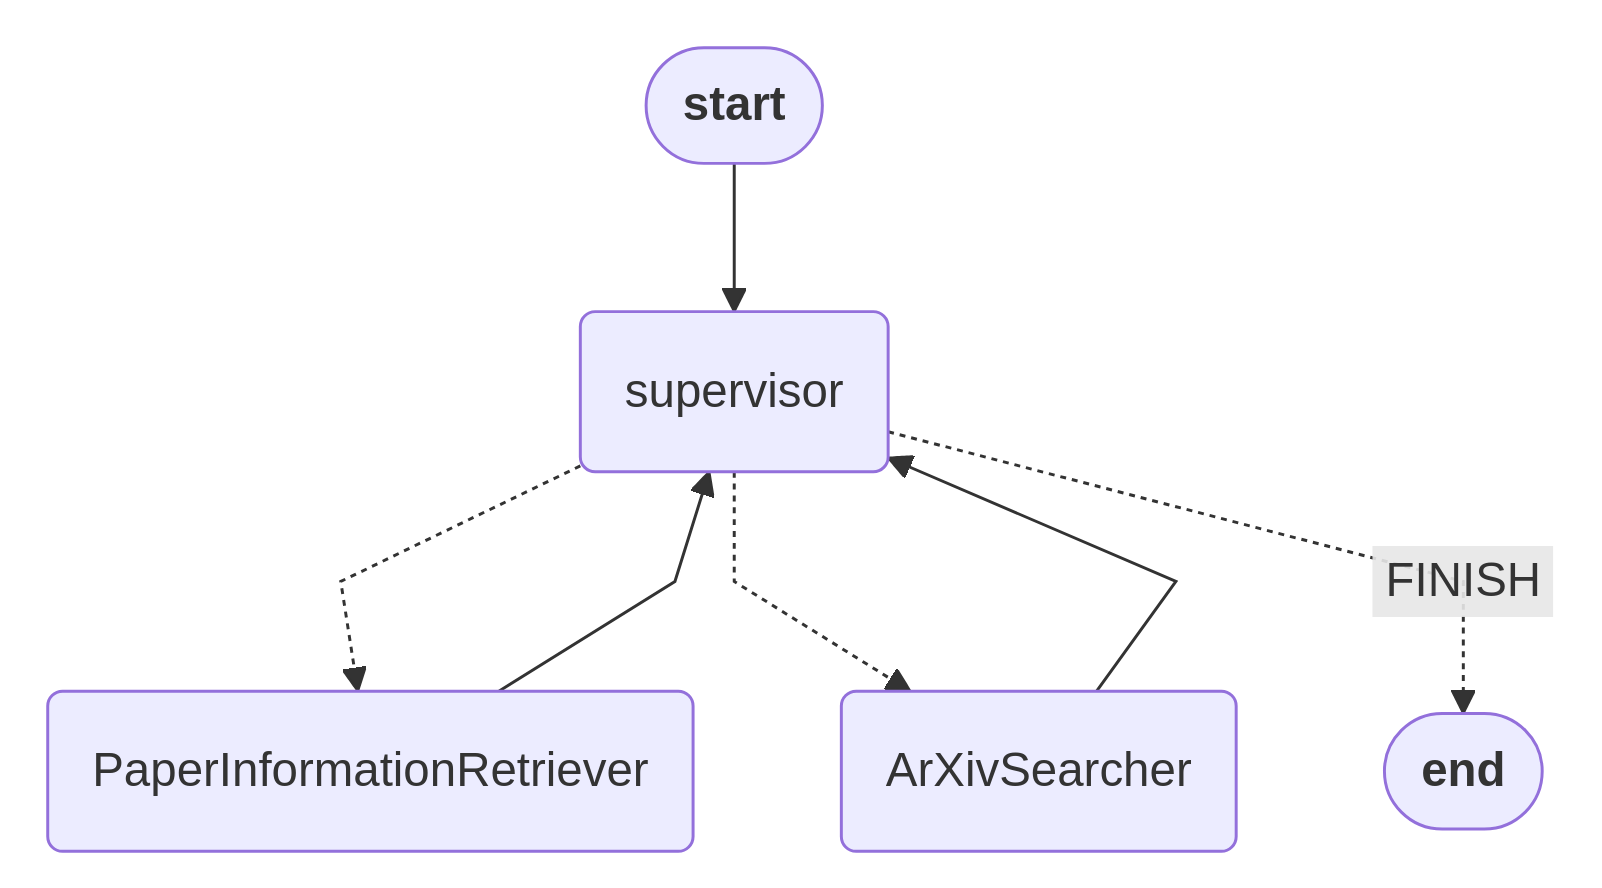

In [31]:
from IPython.display import Image, display
from langchain_core.runnables.graph import CurveStyle, MermaidDrawMethod, NodeStyles

display(
    Image(
        compiled_research_graph.get_graph().draw_mermaid_png(
            curve_style=CurveStyle.LINEAR,
            node_colors=NodeStyles(first="#ffdfba", last="#baffc9", default="#fad7de"),
            wrap_label_n_words=9,
            output_file_path=None,
            draw_method=MermaidDrawMethod.PYPPETEER,
            background_color="white",
            padding=10,
        )
    )
)

The next part is key - since we need to "wrap" our LangGraph in order for it to be compatible in the following steps - let's create an LCEL chain out of it!

This allows us to "broadcast" messages down to our Research Team LangGraph!

In [32]:
def enter_chain(message: str):
    results = {
        "messages": [HumanMessage(content=message)],
    }
    return results

research_chain = enter_chain | compiled_research_graph

Now, finally, we can take it for a spin!

In [33]:
for s in research_chain.stream(
    "What can you tell me about 'lagrangian coherent structures'? Please use ArXivSearch, Search and PaperInformationRetriever!", {"recursion_limit": 100}
):
    if "__end__" not in s:
        if 'supervisor' not in s.keys():
            for response in s.values():
                for msg in response['messages']:
                    msg.pretty_print()
        else:
            print(s)
        print("---")

{'supervisor': {'next': 'ArXivSearcher'}}
---


Bozo feed; consider handling: document declared as utf-8, but parsed as windows-1252


================================ Human Message =================================
Name: ArXivSearcher

I found the following papers related to 'Lagrangian coherent structures':

1. **Three-Dimensional Lagrangian Coherent Structures in Patients with Aortic Regurgitation**
2. **Dissipative Inertial Transport Patterns Near Coherent Lagrangian Eddies in the Ocean**

These papers have been placed into the RAG vector store for further reference.
---
{'supervisor': {'next': 'PaperInformationRetriever'}}
---
================================ Human Message =================================
Name: PaperInformationRetriever

Here are summaries of the papers related to "Lagrangian coherent structures":

1. **Three-Dimensional Lagrangian Coherent Structures in Patients with Aortic Regurgitation**
   - **Authors**: Wissam Abdallah, Ahmed Darwish, Julio Garcia, and Lyes Kadem
   - **Summary**: This study investigates blood transport in cardiovascular flows, specifically in patients with aortic regurgita

##### 🏗️ Activity #2:

Using whatever drawing application you wish - please label the flow above on a diagram of your graph.

##### 🏗️ Activity #2 Response:

> I tried asking a question that would force exercising both agents.

>In my case the flow is:
> `start -> supervisor -> RAG -> supervisor -> search -> supervisor -> END`

![](graph-flow.png)

##### ❓ Question #2:

How could you make sure your Agent uses specific tools that you wish it to use? Are there any ways to concretely set a flow through tools?

##### ❗ Answer #2:

> I would first start with prompt engineering - asking the agent to 
> start by using tool "x" and then continue with "y".

> Alternatively, if we want to absolutely enforce the flow, perhaps 
> a reasoning agent is not the right tool to use (if it doesn't have autonomy, 
> what is there to reason). In that case we may want to enforce the flow
> by setting up a different topology in LangGraph.

> Related to this is an explicit set of options we may give the supervisor.
> In the current application, the "options" in `create_team_supervisor` contain
> all the tools. We could also give it only a partial list (including generating
> that list based on some more explicit logic in the routing function),

# 🤝 BREAKOUT ROOM #2

## Task 4: Document Writing Team - A LangGraph for Writing, Editing, and Planning a LinkedIn post.

Let's run it all back, this time specifically creating tools, agent nodes, and a graph for planning, writing, and editing a LinkedIn post!

### Tool Creation

Let's create some tools that will help us understand, open, work with, and edit documents to our liking!

In [34]:
from pathlib import Path
from tempfile import TemporaryDirectory
from typing import Dict, Optional
from typing_extensions import TypedDict
import uuid
import os

os.makedirs('./content/data', exist_ok=True)

def create_random_subdirectory():
    random_id = str(uuid.uuid4())[:8]  # Use first 8 characters of a UUID
    subdirectory_path = os.path.join('./content/data', random_id)
    os.makedirs(subdirectory_path, exist_ok=True)
    return subdirectory_path

WORKING_DIRECTORY = Path(create_random_subdirectory())

@tool
def create_outline(
    points: Annotated[List[str], "List of main points or sections."],
    file_name: Annotated[str, "File path to save the outline."],
) -> Annotated[str, "Path of the saved outline file."]:
    """Create and save an outline."""
    with (WORKING_DIRECTORY / file_name).open("w") as file:
        for i, point in enumerate(points):
            file.write(f"{i + 1}. {point}\n")
    return f"Outline saved to {file_name}"


@tool
def read_document(
    file_name: Annotated[str, "File path to save the document."],
    start: Annotated[Optional[int], "The start line. Default is 0"] = None,
    end: Annotated[Optional[int], "The end line. Default is None"] = None,
) -> str:
    """Read the specified document."""
    with (WORKING_DIRECTORY / file_name).open("r") as file:
        lines = file.readlines()
    if start is not None:
        start = 0
    return "\n".join(lines[start:end])


@tool
def write_document(
    content: Annotated[str, "Text content to be written into the document."],
    file_name: Annotated[str, "File path to save the document."],
) -> Annotated[str, "Path of the saved document file."]:
    """Create and save a text document."""
    with (WORKING_DIRECTORY / file_name).open("w") as file:
        file.write(content)
    return f"Document saved to {file_name}"


@tool
def edit_document(
    file_name: Annotated[str, "Path of the document to be edited."],
    inserts: Annotated[
        Dict[int, str],
        "Dictionary where key is the line number (1-indexed) and value is the text to be inserted at that line.",
    ] = {},
) -> Annotated[str, "Path of the edited document file."]:
    """Edit a document by inserting text at specific line numbers."""

    with (WORKING_DIRECTORY / file_name).open("r") as file:
        lines = file.readlines()

    sorted_inserts = sorted(inserts.items())

    for line_number, text in sorted_inserts:
        if 1 <= line_number <= len(lines) + 1:
            lines.insert(line_number - 1, text + "\n")
        else:
            return f"Error: Line number {line_number} is out of range."

    with (WORKING_DIRECTORY / file_name).open("w") as file:
        file.writelines(lines)

    return f"Document edited and saved to {file_name}"

##### 🏗️ Activity #3:

Describe, briefly, what each of these tools is doing in your own words.

##### 🏗️ Activity #3 response:

- `create_outline` - takes in a list of titles (strings) and writes an ordered list with those titles into a file
- `read_document` - reads the whole document and returns the segment between line numbers passed as parameters
- `write_document` - writes a string to a file with a given path, overwriting if needed.
- `edit_document`- inserts text at specified line numbers. (Note, since insertion grows the text, the line numbers after the first insertion won't correspond to insertion order. Perhaps a descending list was intended to preserve the order.)

### Document Writing State

Just like with our Research Team state - we want to keep track of a few things, however this time - we also want to keep track of which files we've created - so let's add that here!

In [35]:
import operator
from pathlib import Path

class DocWritingState(TypedDict):
    messages: Annotated[List[BaseMessage], operator.add]
    team_members: str
    next: str
    current_files: str

### Document Writing Prelude Function

Since we have a working directory - we want to be clear about what our current working directory looks like - this helper function will allow us to do that cleanly!

In [36]:
def prelude(state):
    written_files = []
    if not WORKING_DIRECTORY.exists():
        WORKING_DIRECTORY.mkdir()
    try:
        written_files = [
            f.relative_to(WORKING_DIRECTORY) for f in WORKING_DIRECTORY.rglob("*")
        ]
    except:
        pass
    if not written_files:
        return {**state, "current_files": "No files written."}
    return {
        **state,
        "current_files": "\nBelow are files your team has written to the directory:\n"
        + "\n".join([f" - {f}" for f in written_files]),
    }

### Document Writing Node Creation



In [37]:
doc_writer_agent = create_agent(
    llm,
    [write_document, edit_document, read_document],
    ("You are an expert writing technical LinkedIn posts.\n"
    "Below are files currently in your directory:\n{current_files}"),
)
context_aware_doc_writer_agent = prelude | doc_writer_agent
doc_writing_node = functools.partial(
    agent_node, agent=context_aware_doc_writer_agent, name="DocWriter"
)

note_taking_agent = create_agent(
    llm,
    [create_outline, read_document],
    ("You are an expert senior researcher tasked with writing a LinkedIn post outline and"
    " taking notes to craft a LinkedIn post.\n{current_files}"),
)
context_aware_note_taking_agent = prelude | note_taking_agent
note_taking_node = functools.partial(
    agent_node, agent=context_aware_note_taking_agent, name="NoteTaker"
)

copy_editor_agent = create_agent(
    llm,
    [write_document, edit_document, read_document],
    ("You are an expert copy editor who focuses on fixing grammar, spelling, and tone issues\n"
    "Below are files currently in your directory:\n{current_files}"),
)
context_aware_copy_editor_agent = prelude | copy_editor_agent
copy_editing_node = functools.partial(
    agent_node, agent=context_aware_copy_editor_agent, name="CopyEditor"
)

dopeness_editor_agent = create_agent(
    llm,
    [write_document, edit_document, read_document],
    ("You are an expert in dopeness, litness, coolness, etc - you edit the document to make sure it's dope. Make sure to use a number of emojis."
    "Below are files currently in your directory:\n{current_files}"),
)
context_aware_dopeness_editor_agent = prelude | dopeness_editor_agent
dopeness_node = functools.partial(
    agent_node, agent=context_aware_dopeness_editor_agent, name="DopenessEditor"
)

doc_writing_supervisor = create_team_supervisor(
    llm,
    ("You are a supervisor tasked with managing a conversation between the"
    " following workers: {team_members}. You should always verify the technical"
    " contents after any edits are made. "
    "Given the following user request,"
    " respond with the worker to act next. Each worker will perform a"
    " task and respond with their results and status. When each team is finished,"
    " you must respond with FINISH."),
    ["DocWriter", "NoteTaker", "DopenessEditor", "CopyEditor"],
)

### Document Writing Team LangGraph Construction

This part is almost exactly the same (with a few extra nodes) as our Research Team LangGraph construction - so we'll leave it as one block!

In [38]:
authoring_graph = StateGraph(DocWritingState)
authoring_graph.add_node("DocWriter", doc_writing_node)
authoring_graph.add_node("NoteTaker", note_taking_node)
authoring_graph.add_node("CopyEditor", copy_editing_node)
authoring_graph.add_node("DopenessEditor", dopeness_node)
authoring_graph.add_node("supervisor", doc_writing_supervisor)

authoring_graph.add_edge("DocWriter", "supervisor")
authoring_graph.add_edge("NoteTaker", "supervisor")
authoring_graph.add_edge("CopyEditor", "supervisor")
authoring_graph.add_edge("DopenessEditor", "supervisor")

authoring_graph.add_conditional_edges(
    "supervisor",
    lambda x: x["next"],
    {
        "DocWriter": "DocWriter",
        "NoteTaker": "NoteTaker",
        "CopyEditor" : "CopyEditor",
        "DopenessEditor" : "DopenessEditor",
        "FINISH": END,
    },
)

authoring_graph.set_entry_point("supervisor")
compiled_authoring_graph = authoring_graph.compile()

#### Display Graph

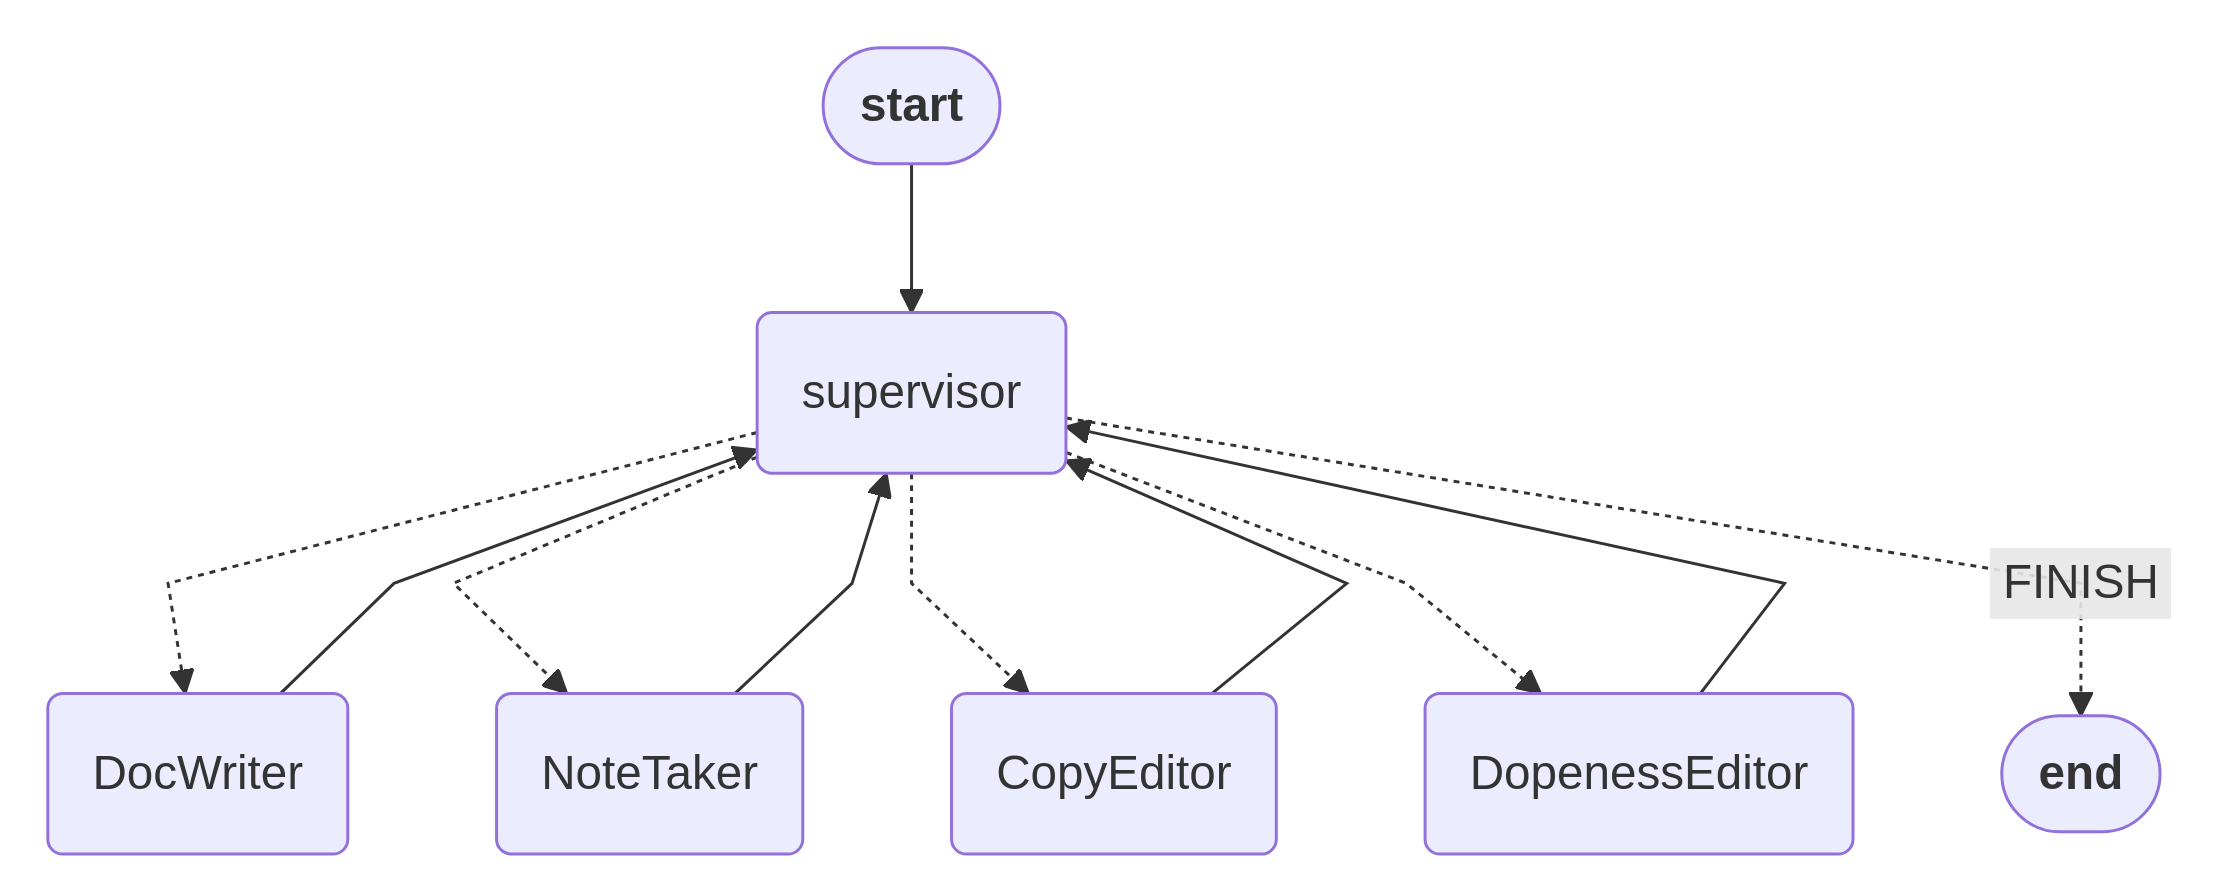

In [39]:
from IPython.display import Image, display

display(
    Image(
        compiled_authoring_graph.get_graph().draw_mermaid_png(
            curve_style=CurveStyle.LINEAR,
            node_colors=NodeStyles(first="#ffdfba", last="#baffc9", default="#fad7de"),
            wrap_label_n_words=9,
            output_file_path=None,
            draw_method=MermaidDrawMethod.PYPPETEER,
            background_color="white",
            padding=10,
        )
    )
)

Just as before - we'll need to create an "interface" between the level above, and our graph.

In [40]:
def enter_chain(message: str, members: List[str]):
    results = {
        "messages": [HumanMessage(content=message)],
        "team_members": ", ".join(members),
    }
    return results

authoring_chain = (
    functools.partial(enter_chain, members=authoring_graph.nodes)
    | authoring_graph.compile()
)

Now we can test this out!

> NOTE: It is possible you may see an error here - rerun the cell to clear.

In [41]:
for s in authoring_chain.stream(
    "Write an outline for for a short LinkedIn post on Linear Regression and write it to disk.",
    {"recursion_limit": 100},
):
        if 'supervisor' not in s.keys():
            for response in s.values():
                for msg in response['messages']:
                    msg.pretty_print()
        else:
            print(s)
        print("---")

{'supervisor': {'next': 'DocWriter'}}
---
================================ Human Message =================================
Name: DocWriter

I have created and saved the outline for a LinkedIn post on Linear Regression. You can find it in the file named "linear_regression_outline.txt".
---
{'supervisor': {'next': 'NoteTaker'}}
---
================================ Human Message =================================
Name: NoteTaker

I have created and saved the outline for a LinkedIn post on Linear Regression. You can find it in the file named "linear_regression_outline.txt".
---
{'supervisor': {'next': 'CopyEditor'}}
---
================================ Human Message =================================
Name: CopyEditor

I have created and saved the outline for a LinkedIn post on Linear Regression in the file named "linear_regression_outline.txt".
---
{'supervisor': {'next': 'DopenessEditor'}}
---
================================ Human Message =================================
Name: DopenessEdi

## Task 5: Meta-Supervisor and Full Graph

Finally, now that we have our two LangGraph agents (some of which are already multi-agent), we can build a supervisor that sits above all of them!

The final process, surprisingly, is quite straight forward!

Let's jump in!

First off - we'll need to create our supervisor agent node.

In [42]:
from langchain_core.messages import AIMessage, BaseMessage, HumanMessage
from langchain_openai.chat_models import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini")

supervisor_node = create_team_supervisor(
    llm,
    "You are a supervisor tasked with managing a conversation between the"
    " following teams: {team_members}. Given the following user request,"
    " respond with the worker to act next. Each worker will perform a"
    " task and respond with their results and status. When all workers are finished,"
    " you must respond with FINISH.",
    ["Research team", "LinkedIn team"],
)

We'll also create our new state - as well as some methods to help us navigate the new state and the subgraphs.

> NOTE: We only pass the most recent message from the parent graph to the subgraph, and we only extract the most recent message from the subgraph to include in the state of the parent graph.

In [43]:
class State(TypedDict):
    messages: Annotated[List[BaseMessage], operator.add]
    next: str

def get_last_message(state: State) -> str:
    return state["messages"][-1].content

def join_graph(response: dict):
    return {"messages": [response["messages"][-1]]}

Next, we'll create our base graph.

Notice how each node we're adding is *AN ENTIRE LANGGRAPH AGENT* (wrapped into an LCEL chain with our helper functions above).

In [44]:
super_graph = StateGraph(State)

super_graph.add_node("Research team", get_last_message | research_chain | join_graph)
super_graph.add_node(
    "LinkedIn team", get_last_message | authoring_chain | join_graph
)
super_graph.add_node("supervisor", supervisor_node)

Next, we'll create our edges!

This process is completely idenctical to what we've seen before - just addressing the LangGraph subgraph nodes instead of individual nodes.

In [45]:
super_graph.add_edge("Research team", "supervisor")
super_graph.add_edge("LinkedIn team", "supervisor")
super_graph.add_conditional_edges(
    "supervisor",
    lambda x: x["next"],
    {
        "LinkedIn team": "LinkedIn team",
        "Research team": "Research team",
        "FINISH": END,
    },
)
super_graph.set_entry_point("supervisor")
compiled_super_graph = super_graph.compile()

That's it!

Now we can finally use our full agent!

In [46]:
WORKING_DIRECTORY = Path(create_random_subdirectory())

for s in compiled_super_graph.stream(
    {
        "messages": [
            HumanMessage(
                content="Write a LinkedIn post on the topic of 'Lagrangian Coherent Structures'. First consult the research team. Then make sure you consult the LinkedIn team, and check for copy editing and dopeness, and write the file to disk."
            )
        ],
    },
    {"recursion_limit": 30},
):
    if 'supervisor' not in s.keys():
        for response in s.values():
            for msg in response['messages']:
                msg.pretty_print()
    else:
        print(s)
    print("---")

{'supervisor': {'next': 'Research team'}}
---


Bozo feed; consider handling: document declared as utf-8, but parsed as windows-1252


================================ Human Message =================================
Name: PaperInformationRetriever

Here’s an updated LinkedIn post on the topic of 'Lagrangian Coherent Structures' based on recent research findings:

---

🌊 **Exploring Lagrangian Coherent Structures in Fluid Dynamics** 🌊

In the intricate world of fluid dynamics, Lagrangian Coherent Structures (LCS) are vital for understanding transport and mixing processes within flows. These structures identify regions of coherent motion where fluid particles gather or disperse over time, providing insights into the dynamics of fluid motion.

Recent research highlights the significance of LCS beyond traditional boundaries. For instance, the study "Three-Dimensional Lagrangian Coherent Structures in Patients with Aortic Regurgitation" illustrates their medical applications, showcasing how LCS can inform cardiac flow dynamics. Additionally, the paper "Dissipative Inertial Transport Patterns Near Coherent Lagrangian Eddies

## SAMPLE POST!

🌊 **Exploring Lagrangian Coherent Structures in Fluid Dynamics** 🌊

In the intricate world of fluid dynamics, Lagrangian Coherent Structures (LCS) are vital for understanding transport and mixing processes within flows. These structures identify regions of coherent motion where fluid particles gather or disperse over time, providing insights into the dynamics of fluid motion.

Recent research highlights the significance of LCS beyond traditional boundaries. For instance, the study "Three-Dimensional Lagrangian Coherent Structures in Patients with Aortic Regurgitation" illustrates their medical applications, showcasing how LCS can inform cardiac flow dynamics. Additionally, the paper "Dissipative Inertial Transport Patterns Near Coherent Lagrangian Eddies in the Ocean" reveals how these structures enhance our understanding of ocean currents and their ecological implications.

LCS can be categorized into **elliptic** and **hyperbolic** structures. Elliptic LCS are characterized by closed loops where fluid particles tend to remain together, while hyperbolic LCS exhibit attracting and repelling behaviors that influence particle movements. This categorization helps explain various phenomena, such as the trajectories of drifting buoys and the distribution of floating matter in oceans.

Moreover, inertial effects, including buoyancy and particle size, modify the behavior of particles in relation to LCS, leading to intricate transport patterns even near coherent eddies. This interplay is crucial for understanding transport in ocean environments.

As we continue to unlock the mysteries of fluid behavior, leveraging Lagrangian methods can advance research and applications across disciplines—from engineering to environmental science. Let's embrace the complexity of fluid dynamics and harness the power of Lagrangian Coherent Structures! 🌍

#FluidDynamics #LagrangianCoherentStructures #Research #Innovation #Science


In [47]:
WORKING_DIRECTORY = Path(create_random_subdirectory())

for s in compiled_super_graph.stream(
    {
        "messages": [
            HumanMessage(
                content="Write a LinkedIn post on the topic of 'Topological Data Analysis' in physics. First consult the research team. Then make sure you consult the LinkedIn team, and check for copy editing and dopeness, and write the file to disk."
            )
        ],
    },
    {"recursion_limit": 30},
):
    if 'supervisor' not in s.keys():
        for response in s.values():
            for msg in response['messages']:
                msg.pretty_print()
    else:
        print(s)
    print("---")
    
print(WORKING_DIRECTORY)

{'supervisor': {'next': 'Research team'}}
---
================================ Human Message =================================
Name: PaperInformationRetriever

Here's an updated LinkedIn post on the topic of 'Topological Data Analysis' in physics, incorporating insights from recent research:

---

🔍 **Exploring Topological Data Analysis in Physics** 🌌

In recent years, **Topological Data Analysis (TDA)** has emerged as a powerful tool in the realm of physics, allowing researchers to uncover hidden structures and patterns within complex datasets. TDA’s ability to study the shape of data provides a unique perspective, particularly in understanding phenomena such as phase transitions and topological phases of matter.

Recent research highlights TDA's profound impact when combined with machine learning, showcasing its potential to analyze high-dimensional data across various fields, from condensed matter physics to cosmology. Techniques like **persistent homology** enable the compression o

🔍 **Exploring Topological Data Analysis (TDA) in Physics**

1. **Introduction to TDA**  
   Topological Data Analysis (TDA) is revolutionizing how we interpret complex datasets in physics. By utilizing techniques from topology, TDA helps unravel the shape of data, revealing hidden structures often missed by traditional methods.

2. **Uncovering Hidden Structures**  
   Whether it's intricate multi-dimensional data or patterns within complex systems, TDA excels in illuminating relationships that guide innovative research in physics.

3. **Synergy with Machine Learning**  
   The integration of TDA with machine learning is a game-changer, enhancing data analysis capabilities and providing deeper insights into the intricacies of physical phenomena.

4. **Persistent Homology Techniques**  
   Key techniques like persistent homology enable the analysis of features across multiple scales, with applications ranging from phase transitions to quantum state structures, offering insights that were previously unattainable.

5. **Insights into 3D Topological Orders**  
   Recent advancements in TDA are shedding light on continuum field theory and 3D topological orders, potentially reshaping our understanding of quantum materials.

6. **Need for Standardization**  
   As TDA gains traction, standardization of methods is crucial for ensuring reproducibility and reliability, as highlighted in recent reviews.

7. **Future Prospects**  
   The future of TDA in physics is bright, with the potential to redefine our comprehension of the universe and its fundamental laws.

8. **Call to Action**  
   I invite fellow researchers and enthusiasts to connect and share insights on TDA in physics. Together, we can explore its vast potential and propel the field forward!
   